# Регрессия для датасета 
**Цель:** предсказать целевую переменную Bilirubin.


# Метрики регрессии

В ноутбуке считаются следующие метрики:

- **MAE** — средняя абсолютная ошибка;
- **MSE** — среднеквадратичная ошибка;
- **RMSE** — корень из среднеквадратичной ошибки;
- **R2** — коэффициент детерминации;
- **Adjusted R2** — скорректированный коэффициент детерминации;
- **CV R2** — средний `R2` по кросс-валидации.


In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, ElasticNet, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

RANDOM_STATE = 100

In [5]:
DATA_PATH = "D:/ProjectAI/ai_brief-main/cirrhosis_preprocessed.csv"

# Загрузка и первичный анализ данных

In [14]:
df = pd.read_csv(DATA_PATH)
df.head()


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_years
0,1,400,2.0000,0.0000,21464,0.0000,1.0000,1.0000,1.0000,2.0000,14.5000,261.0000,2.6000,156.0000,1718.0000,137.9500,172.0000,190.0000,12.2000,4.0000,58.8055
1,2,4500,0.0000,0.0000,20617,0.0000,0.0000,1.0000,1.0000,0.0000,1.1000,302.0000,4.1400,54.0000,7394.8000,113.5200,88.0000,221.0000,10.6000,3.0000,56.4849
2,3,1012,2.0000,0.0000,25594,1.0000,0.0000,0.0000,0.0000,1.0000,1.4000,176.0000,3.4800,210.0000,516.0000,96.1000,55.0000,151.0000,12.0000,4.0000,70.1205
3,4,1925,2.0000,0.0000,19994,0.0000,0.0000,1.0000,1.0000,1.0000,1.8000,244.0000,2.5400,64.0000,6121.8000,60.6300,92.0000,183.0000,10.3000,4.0000,54.7781
4,5,1504,1.0000,1.0000,13918,0.0000,0.0000,1.0000,1.0000,0.0000,3.4000,279.0000,3.5300,143.0000,671.0000,113.1500,72.0000,136.0000,10.9000,3.0000,38.1315


In [15]:
summary_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique(),
})

display(summary_df)
display(df.describe().T)


,dtype,missing_values,unique_values
ID,int64,0,312
N_Days,int64,0,301
Status,float64,0,3
Drug,float64,0,2
Age,int64,0,308
Sex,float64,0,2
Ascites,float64,0,2
Hepatomegaly,float64,0,2
Spiders,float64,0,2
Edema,float64,0,3


,count,mean,std,min,25%,50%,75%,max
ID,312.0000,156.5000,90.2109,1.0000,78.7500,156.5000,234.2500,312.0000
N_Days,312.0000,2006.3622,1123.2808,41.0000,1191.0000,1839.5000,2697.2500,4556.0000
Status,312.0000,0.8622,0.9608,0.0000,0.0000,0.0000,2.0000,2.0000
Drug,312.0000,0.4936,0.5008,0.0000,0.0000,0.0000,1.0000,1.0000
Age,312.0000,18269.4423,3864.8054,9598.0000,15427.7500,18187.5000,20715.0000,28650.0000
Sex,312.0000,0.1154,0.3200,0.0000,0.0000,0.0000,0.0000,1.0000
Ascites,312.0000,0.0769,0.2669,0.0000,0.0000,0.0000,0.0000,1.0000
Hepatomegaly,312.0000,0.5128,0.5006,0.0000,0.0000,1.0000,1.0000,1.0000
Spiders,312.0000,0.2885,0.4538,0.0000,0.0000,0.0000,1.0000,1.0000
Edema,312.0000,0.2212,0.5490,0.0000,0.0000,0.0000,0.0000,2.0000


In [16]:
target_corr = (
    df.corr(numeric_only=True)['Bilirubin']
      .drop('Bilirubin')
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('Топ признаков по абсолютной корреляции с Bilirubin:')
display(target_corr.to_frame(name='corr_with_bilirubin').head(10))


Топ признаков по абсолютной корреляции с Bilirubin:


,corr_with_bilirubin
Copper,0.4574
N_Days,-0.4418
SGOT,0.4417
Status,0.4368
Tryglicerides,0.4184
Edema,0.4046
Cholesterol,0.3805
Ascites,0.3783
Prothrombin,0.3617
Albumin,-0.3346


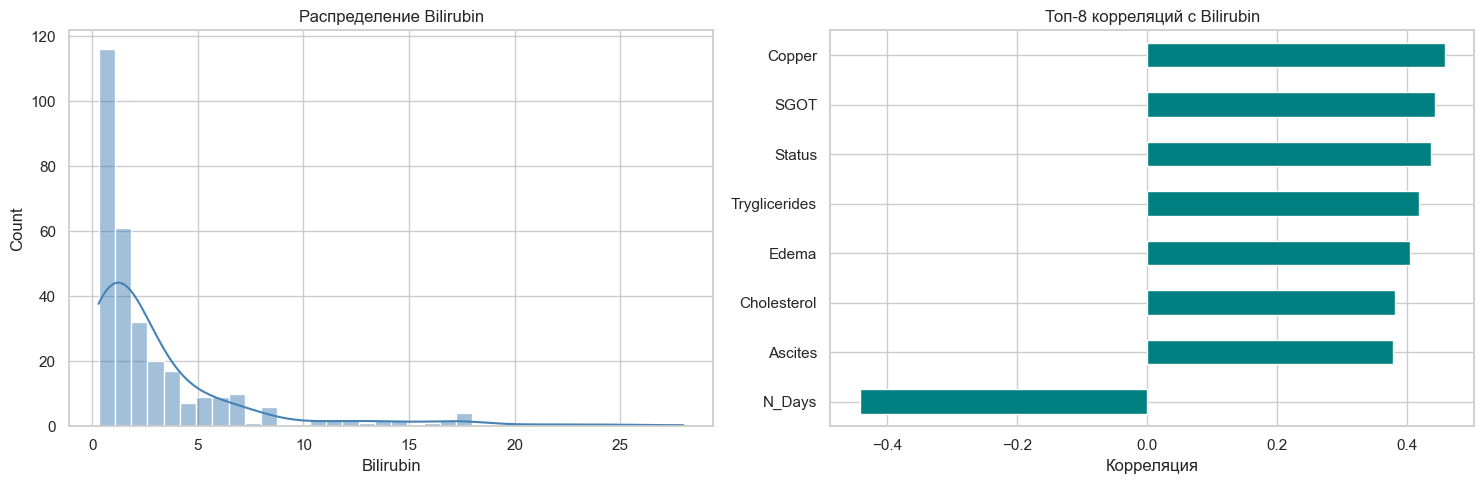

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Bilirubin'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение Bilirubin')
axes[0].set_xlabel('Bilirubin')

plot_corr = target_corr.head(8).sort_values()
plot_corr.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Топ-8 корреляций с Bilirubin')
axes[1].set_xlabel('Корреляция')

plt.tight_layout()
plt.show()


# Подготовка данных к обучению

In [18]:
X = df.drop(columns=['Bilirubin', 'ID'])
y = df['Bilirubin']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_corr = X_train.copy()
train_corr['Bilirubin'] = y_train.values
poly_features = (
    train_corr.corr(numeric_only=True)['Bilirubin']
    .drop('Bilirubin')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(6)
    .index
    .tolist()
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Признаки для полиномиальной модели: {poly_features}')


X_train shape: (249, 19)
X_test shape: (63, 19)
Признаки для полиномиальной модели: ['SGOT', 'Copper', 'Status', 'N_Days', 'Tryglicerides', 'Edema']







В этой ячейке создаётся функция для оценки качества регрессионных моделей. Она позволяет для каждой обученной модели рассчитать основные метрики качества: MAE, MSE, RMSE, R2 и скорректированный R2, а также среднее значение R2 по кросс-валидации. Полученные результаты сохраняются для последующего сравнения моделей и выводятся в виде удобной таблицы:




In [19]:
results = []
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_regression_model(model, model_name, X_train_eval, y_train_eval, X_test_eval, y_test_eval, y_pred, num_features=None):
    cv_r2 = cross_val_score(
        estimator=model,
        X=X_train_eval,
        y=y_train_eval,
        cv=cv,
        scoring='r2',
        n_jobs=1,
    ).mean()

    mae = mean_absolute_error(y_test_eval, y_pred)
    mse = mean_squared_error(y_test_eval, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_eval, y_pred)

    n = X_test_eval.shape[0]
    p = num_features if num_features is not None else X_test_eval.shape[1]
    adjusted_r2 = np.nan
    if n - p - 1 > 0:
        adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    row = {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted_R2': adjusted_r2,
        'CV_R2': cv_r2,
    }
    results.append(row)

    return pd.DataFrame([row]).round(4)


# Линейная регрессия

In [20]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

display(
    evaluate_regression_model(
        linear_model,
        'Linear Regression',
        X_train,
        y_train,
        X_test,
        y_test,
        y_pred_linear,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,Linear Regression,1.7966,4.7836,2.1872,0.5456,0.3448,0.5168


# Полиномиальная регрессия

Чтобы избежать слишком большого числа полиномиальных признаков, строим модель только на 6 признаках с наибольшей корреляцией с `Bilirubin` и добавляем `Ridge`-регуляризацию.


In [21]:
X_train_poly = X_train[poly_features]
X_test_poly = X_test[poly_features]

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0)),
])

poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

poly_feature_count = poly_model.named_steps['poly'].transform(X_train_poly).shape[1]

display(
    evaluate_regression_model(
        poly_model,
        'Polynomial Regression (deg=2 + Ridge)',
        X_train_poly,
        y_train,
        X_test_poly,
        y_test,
        y_pred_poly,
        num_features=poly_feature_count,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,Polynomial Regression (deg=2 + Ridge),1.3941,3.4985,1.8704,0.6676,0.4113,0.4297


# Регрессия дерева решений

In [22]:
tree_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

display(
    evaluate_regression_model(
        tree_model,
        'Decision Tree',
        X_train,
        y_train,
        X_test,
        y_test,
        y_pred_tree,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,Decision Tree,1.3204,7.2921,2.7004,0.3072,0.0012,0.3184


# Регрессия случайного леса

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

display(
    evaluate_regression_model(
        rf_model,
        'Random Forest',
        X_train,
        y_train,
        X_test,
        y_test,
        y_pred_rf,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,Random Forest,1.1378,3.3667,1.8348,0.6802,0.5388,0.5370


# Регрессия опорных векторов (SVR)

In [24]:
svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=25, epsilon=0.2)),
])

svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

display(
    evaluate_regression_model(
        svr_model,
        'SVR (RBF)',
        X_train,
        y_train,
        X_test,
        y_test,
        y_pred_svr,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,SVR (RBF),1.2721,3.1426,1.7727,0.7015,0.5695,0.4451


# Регрессия ElasticNet

In [25]:
elastic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNet(alpha=0.05, l1_ratio=0.3, max_iter=20000, random_state=RANDOM_STATE)),
])

elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)

display(
    evaluate_regression_model(
        elastic_model,
        'ElasticNet',
        X_train,
        y_train,
        X_test,
        y_test,
        y_pred_elastic,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,ElasticNet,1.7694,4.6805,2.1634,0.5554,0.3589,0.5252


# Дополнительный ансамблевый метод: Extra Trees

In [26]:
extra_trees_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

extra_trees_model.fit(X_train, y_train)
y_pred_extra = extra_trees_model.predict(X_test)

display(
    evaluate_regression_model(
        extra_trees_model,
        'Extra Trees',
        X_train,
        y_train,
        X_test,
        y_test,
        y_pred_extra,
    )
)


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,Extra Trees,1.1186,2.7552,1.6599,0.7383,0.6226,0.4390


# Сводная таблица метрик

In [27]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
display(results_df.round(4))

best_model_name = results_df.iloc[0]['Model']
print(f'Лучшая модель на тестовой выборке: {best_model_name}')


,Model,MAE,MSE,RMSE,R2,Adjusted_R2,CV_R2
0,Extra Trees,1.1186,2.7552,1.6599,0.7383,0.6226,0.4390
1,SVR (RBF),1.2721,3.1426,1.7727,0.7015,0.5695,0.4451
2,Random Forest,1.1378,3.3667,1.8348,0.6802,0.5388,0.5370
3,Polynomial Regression (deg=2 + Ridge),1.3941,3.4985,1.8704,0.6676,0.4113,0.4297
4,ElasticNet,1.7694,4.6805,2.1634,0.5554,0.3589,0.5252
5,Linear Regression,1.7966,4.7836,2.1872,0.5456,0.3448,0.5168
6,Decision Tree,1.3204,7.2921,2.7004,0.3072,0.0012,0.3184


Лучшая модель на тестовой выборке: Extra Trees


# Визуализация регрессии по одному признаку

Для наглядности возьмем один параметр Copper и построим одномерную полиномиальную регрессию

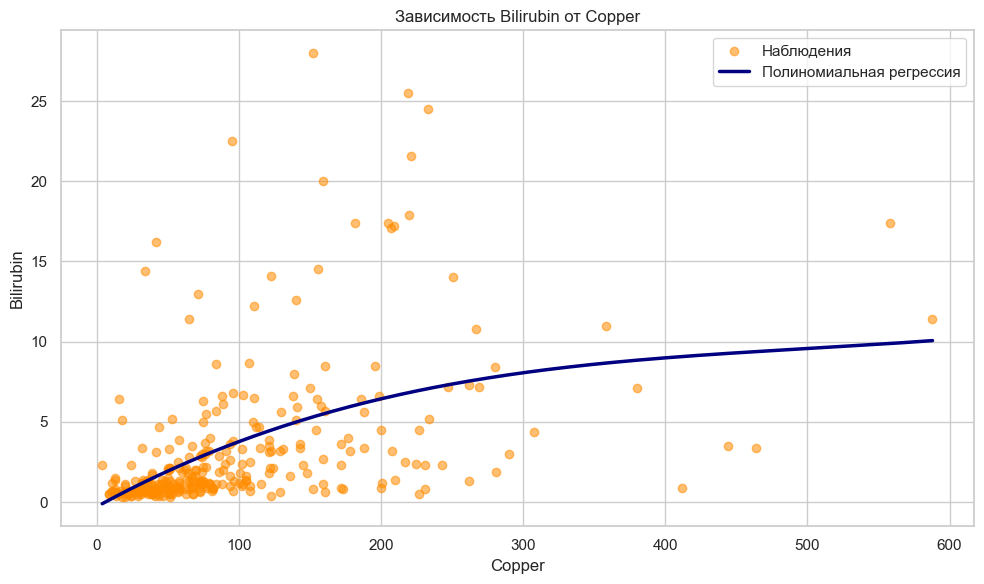

In [28]:
feature_for_plot = 'Copper'
X_plot = df[[feature_for_plot]]
y_plot = df['Bilirubin']

plot_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0)),
])
plot_model.fit(X_plot, y_plot)

x_grid = np.linspace(X_plot[feature_for_plot].min(), X_plot[feature_for_plot].max(), 300)
x_grid_df = pd.DataFrame({feature_for_plot: x_grid})
y_grid = plot_model.predict(x_grid_df)

plt.figure(figsize=(10, 6))
plt.scatter(X_plot[feature_for_plot], y_plot, alpha=0.55, color='darkorange', label='Наблюдения')
plt.plot(x_grid, y_grid, color='navy', linewidth=2.5, label='Полиномиальная регрессия')
plt.title('Зависимость Bilirubin от Copper')
plt.xlabel('Copper')
plt.ylabel('Bilirubin')
plt.legend()
plt.tight_layout()
plt.show()


# Вывод

1. На выбранном разбиении лучший результат показал один из ансамблевых методов.
2. Для визуализации по одному признаку Copper видно, что связь с Bilirubin нелинейная, поэтому нелинейные модели здесь уместны.
